In [5]:
# Install the evolve framework in editable mode
import subprocess
import sys

# Install in editable mode
subprocess.check_call(
    [sys.executable, "-m", "pip", "install", "-q", "-e", "/Users/lucasflores/evolve-framework"]
)

# Add the parent directory to sys.path as a fallback
import os

parent_dir = os.path.abspath("/Users/lucasflores/evolve-framework")
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)

print("✓ Package installed successfully!")
print(f"✓ Python path includes: {parent_dir}")

# Test import
try:
    import evolve

    print(f"✓ evolve module found at: {evolve.__file__}")
except ImportError as e:
    print(f"✗ Failed to import evolve: {e}")

✓ Package installed successfully!
✓ Python path includes: /Users/lucasflores/evolve-framework
✓ evolve module found at: /Users/lucasflores/evolve-framework/evolve/__init__.py


# Tutorial 1: VectorGenome - Continuous Optimization with Evolution

**Learning Objectives:**
- Understand evolutionary algorithm basics through ML-familiar analogies
- Map EA concepts to machine learning equivalents (genome→weights, fitness→-loss)
- Implement continuous optimization using VectorGenome representation
- Visualize evolution progress, diversity, and convergence
- Use callbacks for logging and checkpointing
- Compare single vs island model parallelism

**Prerequisites:**
- Python 3.10+
- Statistics and linear algebra background
- No evolutionary algorithm experience required

**Estimated time:** 45-60 minutes

## Setup and Imports

First, let's import the necessary modules. We'll use:
- `evolve` - The main framework for evolutionary algorithms
- `tutorial_utils` - Visualization and benchmark utilities
- Standard scientific Python stack (numpy, matplotlib)

In [ ]:
# Core framework imports
from random import Random

# Plotting
import matplotlib.pyplot as plt
import numpy as np

# Tutorial utilities
from docs.tutorials.utils.tutorial_utils import (
    EVOLUTIONARY_LOOP_DIAGRAM,
    GENOME_PHENOTYPE_DIAGRAM,
    ISLAND_MODEL_DIAGRAM,
    BenchmarkResult,
    # Visualization
    EvolutionHistory,
    # GPU utilities
    check_gpu_available,
    get_benchmark,
    # Terminology
    plot_fitness_history,
    plot_population_diversity,
    print_glossary_table,
    rastrigin_function,
    # Diagrams
    render_mermaid,
    sphere_function,
)

# Operator classes for "Under the Hood" demos
from evolve import (
    GaussianMutation,
    UniformCrossover,
    VectorGenome,
)

# Evolve framework — declarative configuration
from evolve.config import UnifiedConfig
from evolve.factory import create_engine, create_initial_population

%matplotlib inline

# Reproducibility
SEED = 42
np.random.seed(SEED)

print("✓ All imports successful!")

✓ All imports successful!


---

## Part 1: EA Primer with ML Analogies

If you're coming from machine learning, evolutionary algorithms (EAs) might seem unfamiliar at first. But the core concepts map cleanly to ideas you already know.

### The Key Insight

**Gradient descent explores a loss landscape by following gradients.**  
**Evolution explores a fitness landscape by sampling and selection.**

Both are optimization methods, just with different strategies for finding good solutions.

### EA-to-ML Terminology Mapping

Let's see how EA terms map to concepts you already know:

In [9]:
# Display the terminology mapping table
print_glossary_table()

EA Term,ML Analogy,Biology Origin,Explanation
Genome,Model weights,DNA,"Complete parameter encoding of a solution. Like neural network weights, the genome contains all the information needed to produce behavior."
Phenotype,Model behavior/predictions,Organism,"The decoded/evaluated form of a genome. The phenotype is what gets evaluated for fitness, similar to how model predictions are what get scored."
Fitness,-Loss (negative loss),Survival/reproductive success,"Quality measure we maximize. Higher fitness = better solution. For minimization problems, fitness = -objective_value."
Population,Ensemble of models,Species,Collection of candidate solutions maintained simultaneously. Like maintaining multiple model instances to explore solution space.
Generation,Epoch/iteration,Lifespan,One full cycle of selection and variation. Each generation produces a new population from the previous one.
Selection,Sampling by quality,Natural selection,Choosing individuals to be parents based on fitness. Higher fitness = higher probability of being selected. Like importance sampling.
Crossover,Weight interpolation,Sexual reproduction,Combining information from two parents to create offspring. Similar to model interpolation or mixing weight matrices.
Mutation,Gradient noise / perturbation,Random mutation,"Small random changes to a genome. Enables exploration of nearby solutions, similar to adding noise to gradients or weights."
Elitism,Best checkpoint preservation,N/A (artificial),"Preserving the top performers unchanged into the next generation. Guarantees best fitness never decreases, like saving best model checkpoint."
Diversity,Ensemble variance,Biodiversity,Spread of population in solution space. High diversity = exploring widely; low diversity = converging. Prevents premature convergence.


### The Evolutionary Loop

The basic EA loop is analogous to a training loop in deep learning:

| Step | EA | ML Training Loop |
|------|----|-----------------|
| 1 | Initialize population | Initialize weights |
| 2 | Evaluate fitness | Forward pass + loss |
| 3 | Selection | (No direct equivalent) |
| 4 | Crossover + Mutation | Gradient step |
| 5 | Check termination | Check convergence |

Here's the flow as a diagram:

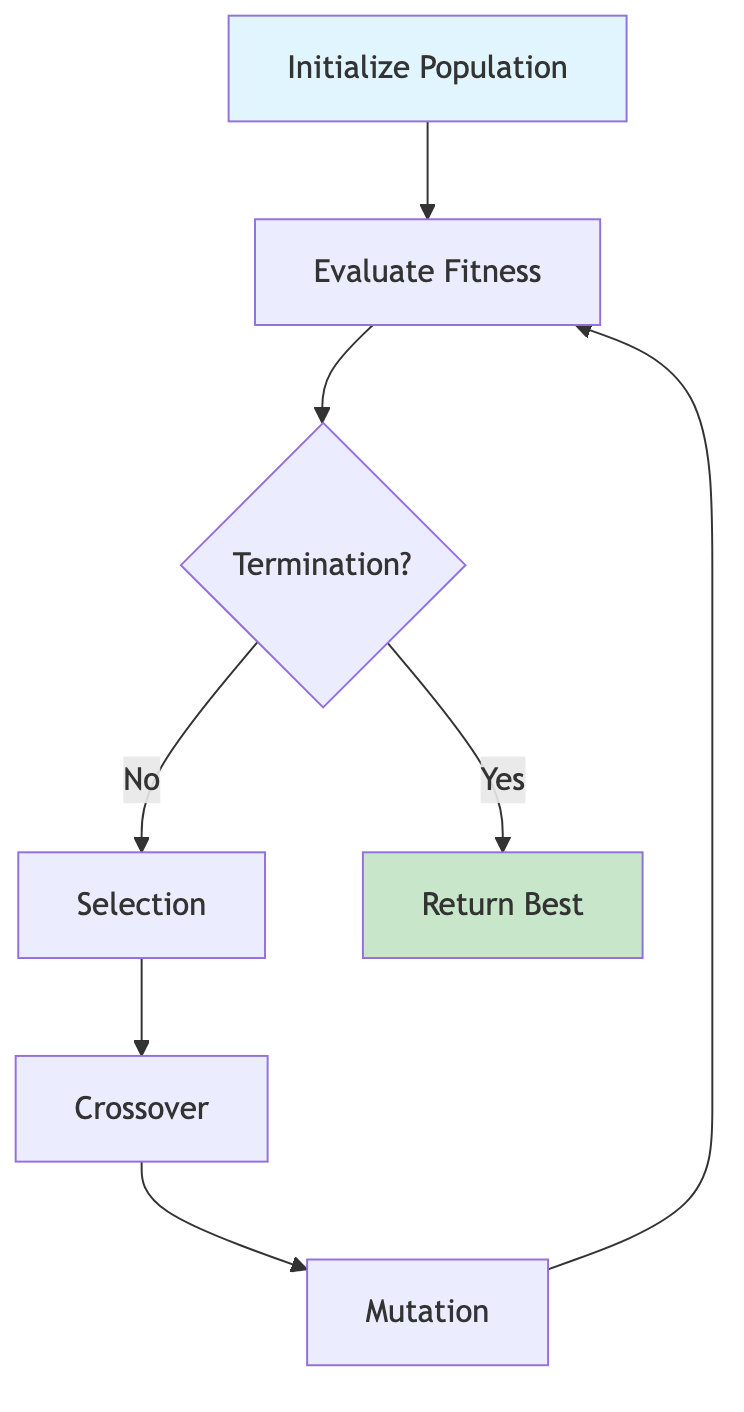

In [10]:
# Render the evolutionary loop diagram
render_mermaid(EVOLUTIONARY_LOOP_DIAGRAM)

### Genome-to-Phenotype: The Encoding Pipeline

A **genome** encodes a solution as a sequence of values (like model weights).  
The **phenotype** is the decoded form that actually gets evaluated.

For VectorGenome, this is often an identity mapping - the genome IS the solution.

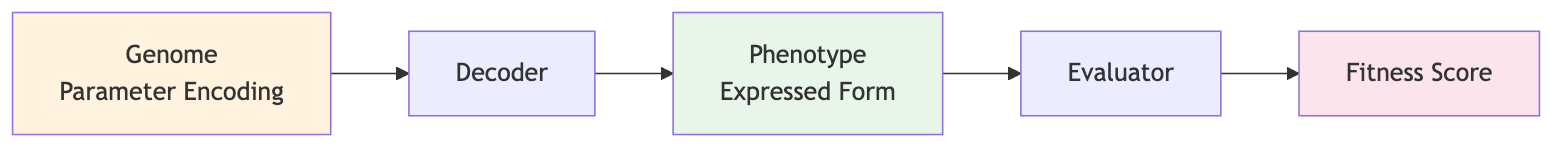

In [11]:
# Visualize genome-to-phenotype pipeline
render_mermaid(GENOME_PHENOTYPE_DIAGRAM)

---

## Part 2: Problem Setup

We'll optimize well-known benchmark functions. These functions have:
- **Known global optima** (for validation)
- **Multiple local minima** (to test exploration)
- **Different difficulty levels**

### Benchmark Functions

| Function | Optimum | Challenge |
|----------|---------|----------|
| Sphere | 0 at origin | Easy, unimodal |
| Rastrigin | 0 at origin | Hard, ~10^n local minima |
| Rosenbrock | 0 at (1,1,...,1) | Medium, narrow valley |

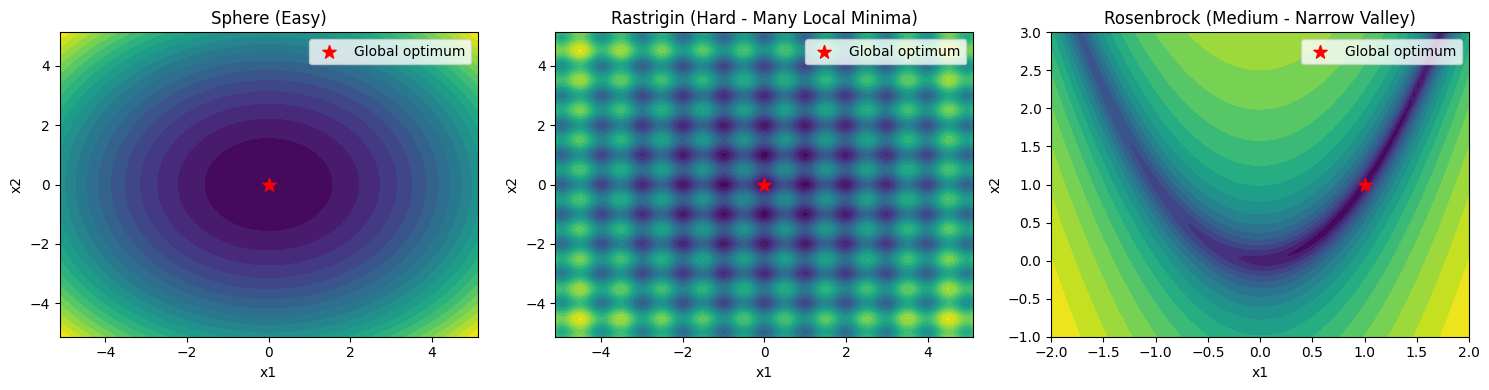

The Rastrigin function is particularly challenging due to its many local minima.
Gradient descent would easily get trapped - evolution explores more broadly!


In [12]:
# Visualize benchmark functions in 2D
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Create grid for visualization
x = np.linspace(-5.12, 5.12, 100)
y = np.linspace(-5.12, 5.12, 100)
X, Y = np.meshgrid(x, y)

# Sphere function
Z_sphere = X**2 + Y**2
ax = axes[0]
c = ax.contourf(X, Y, Z_sphere, levels=20, cmap="viridis")
ax.scatter([0], [0], c="red", s=100, marker="*", label="Global optimum")
ax.set_title("Sphere (Easy)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()

# Rastrigin function
Z_rastrigin = 20 + X**2 + Y**2 - 10 * (np.cos(2 * np.pi * X) + np.cos(2 * np.pi * Y))
ax = axes[1]
c = ax.contourf(X, Y, Z_rastrigin, levels=20, cmap="viridis")
ax.scatter([0], [0], c="red", s=100, marker="*", label="Global optimum")
ax.set_title("Rastrigin (Hard - Many Local Minima)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()

# Rosenbrock (different bounds)
x_rose = np.linspace(-2, 2, 100)
y_rose = np.linspace(-1, 3, 100)
X_rose, Y_rose = np.meshgrid(x_rose, y_rose)
Z_rosenbrock = 100 * (Y_rose - X_rose**2) ** 2 + (1 - X_rose) ** 2
ax = axes[2]
c = ax.contourf(X_rose, Y_rose, np.log10(Z_rosenbrock + 1), levels=20, cmap="viridis")
ax.scatter([1], [1], c="red", s=100, marker="*", label="Global optimum")
ax.set_title("Rosenbrock (Medium - Narrow Valley)")
ax.set_xlabel("x1")
ax.set_ylabel("x2")
ax.legend()

plt.tight_layout()
plt.show()

print("The Rastrigin function is particularly challenging due to its many local minima.")
print("Gradient descent would easily get trapped - evolution explores more broadly!")

---

## Part 3: VectorGenome Representation

A `VectorGenome` is a fixed-length array of real numbers. Think of it like:
- Model weights in a neural network
- Hyperparameters for a model
- Any continuous optimization problem

In [7]:
# Create a VectorGenome manually
genome = VectorGenome(
    genes=np.array([1.5, -0.3, 2.1, 0.0, -1.2]),
    bounds=(np.full(5, -5.12), np.full(5, 5.12)),  # Search bounds
)

print("Genome representation:")
print(f"  Genes: {genome.genes}")
print(f"  Length: {len(genome)}")
print(f"  Bounds: [{genome.bounds[0][0]}, {genome.bounds[1][0]}]")

Genome representation:
  Genes: [ 1.5 -0.3  2.1  0.  -1.2]
  Length: 5
  Bounds: [-5.12, 5.12]


In [14]:
# Create random genomes within bounds
rng = Random(SEED)
n_genes = 10  # 10-dimensional optimization
bounds = (np.full(n_genes, -5.12), np.full(n_genes, 5.12))

# Generate 5 random genomes
print("Random genomes (first 5 genes shown):")
for i in range(5):
    random_genome = VectorGenome.random(n_genes, bounds, rng)
    print(f"  Genome {i + 1}: {random_genome.genes[:5].round(3)}...")

Random genomes (first 5 genes shown):
  Genome 1: [ 1.428 -4.864 -2.304 -2.834  2.421]...
  Genome 2: [-2.881  0.055 -4.848 -3.084  1.535]...
  Genome 3: [ 3.132  2.029 -1.636 -3.528  4.682]...
  Genome 4: [ 3.145  2.352  0.371  4.845 -1.244]...
  Genome 5: [ 2.095 -4.651 -2.786 -2.157 -4.303]...


## Part 4: Mutation Operators

Mutation operators introduce variation by perturbing genes in a genome. The **mutation_rate** parameter is the probability that each gene will be mutated (0.0 to 1.0).

### Available Mutation Operators

**evolve** provides several mutation operators for continuous optimization:

| Operator | Description | Key Parameters | Use Case |
|----------|-------------|----------------|----------|
| **GaussianMutation** | Adds Gaussian noise to genes | `mutation_rate`, `sigma`, `adaptive` | General-purpose, smooth exploration |
| **UniformMutation** | Replaces genes with random values | `mutation_rate` | Large jumps, escaping local optima |
| **PolynomialMutation** | Bounded mutation (NSGA-II style) | `mutation_rate`, `eta` | Multi-objective optimization |
| **CreepMutation** | Small incremental changes | `step_size` | Fine-tuning, exploitation |

### Key Parameters Explained

- **`mutation_rate`**: Probability (0.0-1.0) that each gene will be mutated
  - `0.1` means ~10% of genes change per mutation
  - Higher rate = more exploration, lower rate = more exploitation
  
- **`sigma`** (Gaussian): Standard deviation of noise
  - Controls mutation magnitude
  - `adaptive=True` makes sigma relative to gene bounds
  
- **`eta`** (Polynomial): Distribution index
  - Higher values = smaller mutations (default: 20.0)
  - Lower values = larger mutations
  
- **`rng`** (second argument to `.mutate()`): Random number generator
  - Ensures reproducibility: same seed → same mutations
  - Critical for debugging and scientific experiments

In [8]:
# Compare different mutation operators
from evolve.core.operators import PolynomialMutation, UniformMutation

original = VectorGenome(
    genes=np.array([0.0, 1.0, -1.0, 2.0, -2.0]), bounds=(np.full(5, -5.0), np.full(5, 5.0))
)

print("Original genome:", original.genes)
print("\n" + "=" * 60)

# 1. GaussianMutation: Adds Gaussian noise
print("\n1. GaussianMutation (mutation_rate=0.5, sigma=0.5)")
print("   → Each gene has 50% chance of getting Gaussian noise")

gaussian_mut = GaussianMutation(mutation_rate=0.5, sigma=0.5)
rng = Random(123)
mutated_gaussian = gaussian_mut.mutate(original, rng)

print(f"   Result: {mutated_gaussian.genes.round(3)}")

changed_genes = np.sum(mutated_gaussian.genes != original.genes)
print(f"   Changed: {changed_genes}/5 genes (expected ~2.5 with rate=0.5)")

# Demonstrate RNG reproducibility
result1 = gaussian_mut.mutate(original, Random(123))
result2 = gaussian_mut.mutate(original, Random(123))
result3 = gaussian_mut.mutate(original, Random(456))

print(f"   Random(123): {result1.genes[:3].round(3)}")
print(f"   Same seed = same result: {np.allclose(result1.genes, result2.genes)}")
print(f"   Different seed = different result: {not np.allclose(result1.genes, result3.genes)}")

# 2. UniformMutation: Replaces with random value
print("\n2. UniformMutation (mutation_rate=0.3)")
print("   → Each gene has 30% chance of being replaced with random value")

uniform_mut = UniformMutation(mutation_rate=0.3)
rng = Random(123)
mutated_uniform = uniform_mut.mutate(original, rng)

print(f"   Result: {mutated_uniform.genes.round(3)}")
print("   Note: Mutated genes completely replaced (not perturbed)")

# 3. PolynomialMutation: NSGA-II style bounded mutation
print("\n3. PolynomialMutation (mutation_rate=0.4, eta=20)")
print("   → Higher eta = smaller mutations, common in NSGA-II")

poly_mut = PolynomialMutation(mutation_rate=0.4, eta=20)
rng = Random(123)
mutated_poly = poly_mut.mutate(original, rng)

print(f"   Result: {mutated_poly.genes.round(3)}")

print("\n" + "=" * 60)
print("\n💡 Why pass 'rng' (second argument)?")
print("   → Ensures reproducibility: same seed → same mutations")
print("   → Critical for debugging and research reproducibility")

Original genome: [ 0.  1. -1.  2. -2.]


1. GaussianMutation (mutation_rate=0.5, sigma=0.5)
   → Each gene has 50% chance of getting Gaussian noise
   Result: [ 0.437  1.266 -1.     1.562 -2.   ]
   Changed: 3/5 genes (expected ~2.5 with rate=0.5)
   Random(123): [ 0.437  1.266 -1.   ]
   Same seed = same result: True
   Different seed = different result: True

2. UniformMutation (mutation_rate=0.3)
   → Each gene has 30% chance of being replaced with random value
   Result: [-4.128  1.     4.012  0.362 -2.   ]
   Note: Mutated genes completely replaced (not perturbed)

3. PolynomialMutation (mutation_rate=0.4, eta=20)
   → Higher eta = smaller mutations, common in NSGA-II
   Result: [-0.798  1.    -0.257  2.036 -1.437]


💡 Why pass 'rng' (second argument)?
   → Ensures reproducibility: same seed → same mutations
   → Critical for debugging and research reproducibility


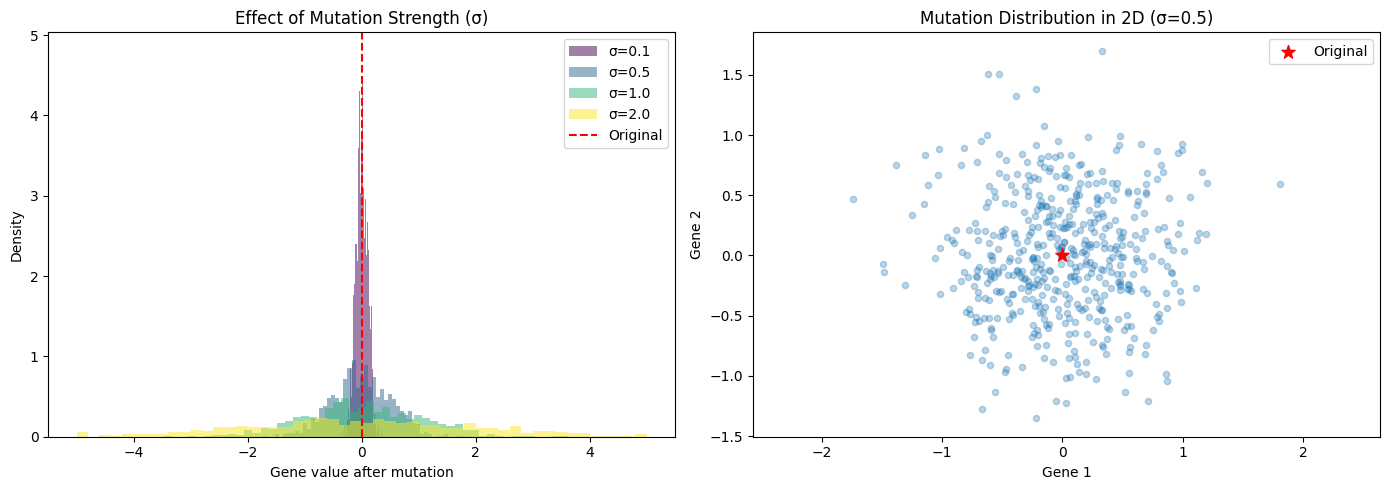


💡 Key insight: Smaller σ = fine-tuning, larger σ = exploration


In [12]:
# Visualize mutation distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Gaussian mutation with different sigma values
ax = axes[0]
sigmas = [0.1, 0.5, 1.0, 2.0]
colors = plt.cm.viridis(np.linspace(0, 1, len(sigmas)))

original_1d = VectorGenome(genes=np.array([0.0]), bounds=(np.array([-5]), np.array([5])))

for sigma, color in zip(sigmas, colors):
    mutation = GaussianMutation(mutation_rate=1.0, sigma=sigma)
    rng = Random(42)

    # Generate many mutations
    changes = []
    for _ in range(1000):
        mutated = mutation.mutate(original_1d, rng)
        changes.append(mutated.genes[0])

    ax.hist(changes, bins=50, alpha=0.5, label=f"σ={sigma}", color=color, density=True)

ax.axvline(x=0, color="red", linestyle="--", label="Original")
ax.set_xlabel("Gene value after mutation")
ax.set_ylabel("Density")
ax.set_title("Effect of Mutation Strength (σ)")
ax.legend()

# 2D scatter of mutations
ax = axes[1]
mutation = GaussianMutation(mutation_rate=1.0, sigma=0.5)
original_2d = VectorGenome(
    genes=np.array([0.0, 0.0]), bounds=(np.array([-5, -5]), np.array([5, 5]))
)

rng = Random(42)
mutated_points = np.array([mutation.mutate(original_2d, rng).genes for _ in range(500)])

ax.scatter(mutated_points[:, 0], mutated_points[:, 1], alpha=0.3, s=20)
ax.scatter([0], [0], c="red", s=100, marker="*", label="Original", zorder=5)
ax.set_xlabel("Gene 1")
ax.set_ylabel("Gene 2")
ax.set_title("Mutation Distribution in 2D (σ=0.5)")
ax.legend()
ax.axis("equal")

plt.tight_layout()
plt.show()

print("\n💡 Key insight: Smaller σ = fine-tuning, larger σ = exploration")

## Part 5: Crossover Operators

**Crossover** combines genetic material from two parent genomes to create offspring. It's analogous to:
- Model averaging/ensembling in ML
- Weight interpolation between neural networks
- Mixing successful partial solutions

### Available Crossover Operators

**evolve** provides several crossover operators for continuous optimization:

| Operator | Description | Key Parameters | Use Case |
|----------|-------------|----------------|----------|
| **UniformCrossover** | Each gene independently from one parent | `swap_prob` | General-purpose, high diversity |
| **SinglePointCrossover** | Split at one point, swap segments | None | Preserving gene blocks/schemas |
| **TwoPointCrossover** | Swap segment between two points | None | Preserving multiple blocks |
| **BlendCrossover** (BLX-α) | Interpolate/extrapolate between parents | `alpha` | Smooth exploration in continuous space |
| **SimulatedBinaryCrossover** (SBX) | NSGA-II style, mimics binary crossover | `eta` | Multi-objective optimization |

### Key Parameters Explained

- **`swap_prob`** (Uniform): Probability (0.0-1.0) of taking gene from parent2
  - `0.5` = equal probability from each parent (standard)
  - Higher values bias toward parent2
  
- **`alpha`** (Blend): Extension factor for interpolation
  - `0.0` = pure interpolation between parents
  - `0.5` = standard BLX-α, can extend 50% beyond parents
  - Creates smooth exploration of solution space
  
- **`eta`** (SBX): Distribution index
  - Higher values = children closer to parents (default: 15.0)
  - Lower values = children can be farther from parents
  - Similar role to `eta` in PolynomialMutation
  
- **`rng`** (third argument to `.crossover()`): Random number generator
  - Ensures reproducibility: same seed → same offspring
  - Critical for debugging and comparing crossover strategies

### When to Use Each Operator

- **Uniform**: Best general-purpose choice, works well for most problems
- **SinglePoint/TwoPoint**: When adjacent genes are functionally related (e.g., neural network layer weights)
- **Blend (BLX-α)**: Continuous optimization with smooth landscapes
- **SBX**: Multi-objective optimization (pairs well with PolynomialMutation)

In [10]:
# Compare different crossover operators
from evolve.core.operators import BlendCrossover, SinglePointCrossover, TwoPointCrossover

# Create distinct parents for clear visualization
parent1 = VectorGenome(
    genes=np.array([1.0, 1.0, 1.0, 1.0, 1.0]), bounds=(np.full(5, -5), np.full(5, 5))
)
parent2 = VectorGenome(
    genes=np.array([9.0, 9.0, 9.0, 9.0, 9.0]), bounds=(np.full(5, -5), np.full(5, 5))
)

print("Parent 1:", parent1.genes)
print("Parent 2:", parent2.genes)
print("\n" + "=" * 60)

# 1. UniformCrossover: Each gene independently from one parent
print("\n1. UniformCrossover (swap_prob=0.5)")
print("   → Each gene has 50% chance of coming from parent1 or parent2")

uniform_cross = UniformCrossover()  # Default swap_prob=0.5
rng = Random(42)
child1, child2 = uniform_cross.crossover(parent1, parent2, rng)

print(f"   Child 1: {child1.genes}")
print(f"   Child 2: {child2.genes}")
print("   Note: Children are 'complementary' (genes swap together)")

# 2. SinglePointCrossover: Split at one point
print("\n2. SinglePointCrossover")
print("   → Split at random point, swap tails")

single_cross = SinglePointCrossover()
rng = Random(42)
child1, child2 = single_cross.crossover(parent1, parent2, rng)

print(f"   Child 1: {child1.genes}")
print(f"   Child 2: {child2.genes}")
print("   Note: Clear split point visible in offspring")

# 3. TwoPointCrossover: Swap segment between two points
print("\n3. TwoPointCrossover")
print("   → Select two points, swap middle segment")

two_cross = TwoPointCrossover()
rng = Random(42)
child1, child2 = two_cross.crossover(parent1, parent2, rng)

print(f"   Child 1: {child1.genes}")
print(f"   Child 2: {child2.genes}")
print("   Note: Middle segment swapped, ends preserved")

# 4. BlendCrossover: Interpolate/extrapolate
print("\n4. BlendCrossover (alpha=0.5)")
print("   → Children are random values in extended range around parents")

blend_cross = BlendCrossover(alpha=0.5)
rng = Random(42)
child1, child2 = blend_cross.crossover(parent1, parent2, rng)

print(f"   Child 1: {child1.genes.round(2)}")
print(f"   Child 2: {child2.genes.round(2)}")
print("   Note: Values between (and slightly beyond) parents")

# Demonstrate RNG reproducibility
print("\n" + "=" * 60)
result1a, result1b = uniform_cross.crossover(parent1, parent2, Random(123))
result2a, result2b = uniform_cross.crossover(parent1, parent2, Random(123))
result3a, result3b = uniform_cross.crossover(parent1, parent2, Random(456))

print("\n💡 RNG reproducibility:")
print(f"   Random(123) child 1: {result1a.genes}")
print(f"   Same seed = same offspring: {np.allclose(result1a.genes, result2a.genes)}")
print(f"   Different seed = different offspring: {not np.allclose(result1a.genes, result3a.genes)}")

Parent 1: [1. 1. 1. 1. 1.]
Parent 2: [9. 9. 9. 9. 9.]


1. UniformCrossover (swap_prob=0.5)
   → Each gene has 50% chance of coming from parent1 or parent2
   Child 1: [1. 9. 9. 9. 1.]
   Child 2: [9. 1. 1. 1. 9.]
   Note: Children are 'complementary' (genes swap together)

2. SinglePointCrossover
   → Split at random point, swap tails
   Child 1: [1. 9. 9. 9. 9.]
   Child 2: [9. 1. 1. 1. 1.]
   Note: Clear split point visible in offspring

3. TwoPointCrossover
   → Select two points, swap middle segment
   Child 1: [1. 9. 9. 9. 1.]
   Child 2: [9. 1. 1. 1. 9.]
   Note: Middle segment swapped, ends preserved

4. BlendCrossover (alpha=0.5)
   → Children are random values in extended range around parents
   Child 1: [5.   1.4  5.   5.   3.75]
   Child 2: [-2.6   0.57  5.   -1.61 -2.52]
   Note: Values between (and slightly beyond) parents


💡 RNG reproducibility:
   Random(123) child 1: [9. 9. 9. 9. 1.]
   Same seed = same offspring: True
   Different seed = different offspring: True


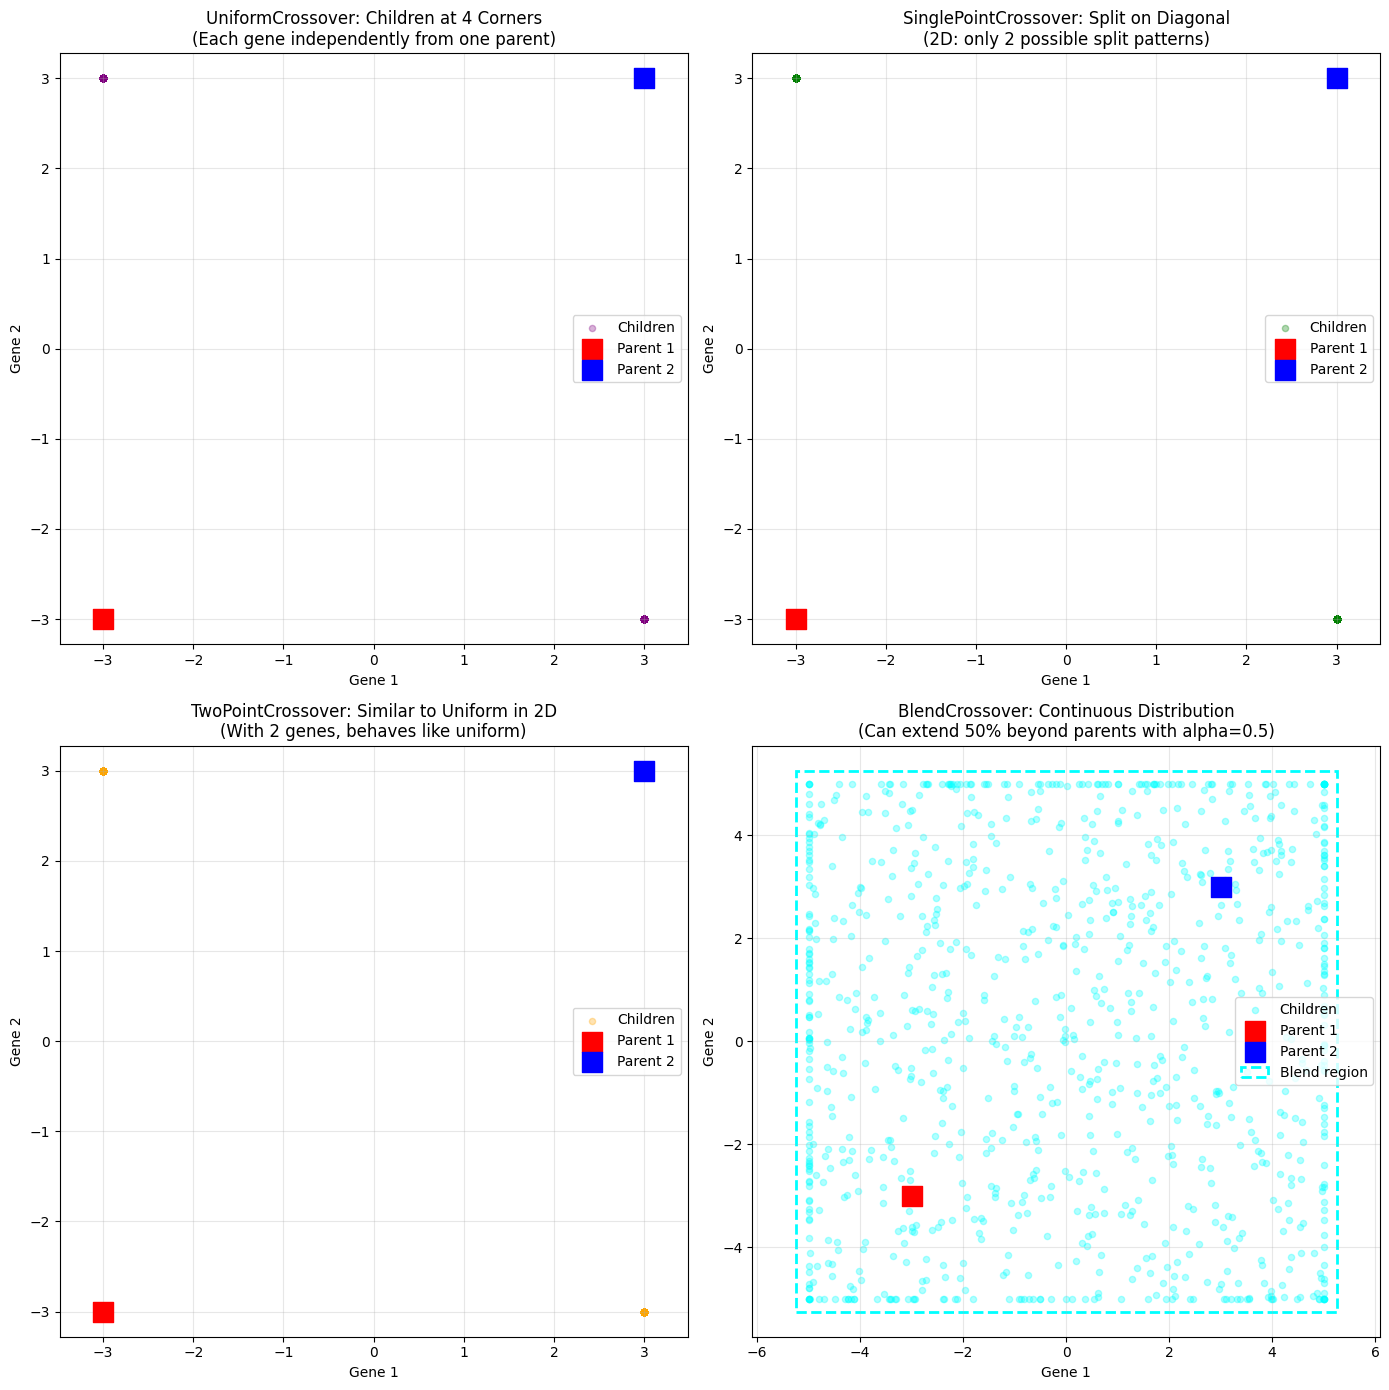


💡 Key insights:
   • Uniform/Point: Discrete combinations (corners/edges)
   • Blend: Continuous distribution (smooth exploration)
   • Choice depends on problem structure and search needs


In [11]:
# Visualize crossover operators in 2D
fig, axes = plt.subplots(2, 2, figsize=(14, 14))

# Parents at opposite corners
parent1_2d = VectorGenome(
    genes=np.array([-3.0, -3.0]), bounds=(np.array([-5, -5]), np.array([5, 5]))
)
parent2_2d = VectorGenome(genes=np.array([3.0, 3.0]), bounds=(np.array([-5, -5]), np.array([5, 5])))

# 1. UniformCrossover
ax = axes[0, 0]
uniform_cross = UniformCrossover()
rng = Random(42)
children = []
for _ in range(500):
    c1, c2 = uniform_cross.crossover(parent1_2d, parent2_2d, rng)
    children.append(c1.genes)
    children.append(c2.genes)
children = np.array(children)

ax.scatter(children[:, 0], children[:, 1], alpha=0.3, s=20, label="Children", color="purple")
ax.scatter(
    [parent1_2d.genes[0]],
    [parent1_2d.genes[1]],
    c="red",
    s=200,
    marker="s",
    label="Parent 1",
    zorder=5,
)
ax.scatter(
    [parent2_2d.genes[0]],
    [parent2_2d.genes[1]],
    c="blue",
    s=200,
    marker="s",
    label="Parent 2",
    zorder=5,
)
ax.set_xlabel("Gene 1")
ax.set_ylabel("Gene 2")
ax.set_title("UniformCrossover: Children at 4 Corners\n(Each gene independently from one parent)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis("equal")

# 2. SinglePointCrossover
ax = axes[0, 1]
single_cross = SinglePointCrossover()
rng = Random(42)
children = []
for _ in range(500):
    c1, c2 = single_cross.crossover(parent1_2d, parent2_2d, rng)
    children.append(c1.genes)
    children.append(c2.genes)
children = np.array(children)

ax.scatter(children[:, 0], children[:, 1], alpha=0.3, s=20, label="Children", color="green")
ax.scatter(
    [parent1_2d.genes[0]],
    [parent1_2d.genes[1]],
    c="red",
    s=200,
    marker="s",
    label="Parent 1",
    zorder=5,
)
ax.scatter(
    [parent2_2d.genes[0]],
    [parent2_2d.genes[1]],
    c="blue",
    s=200,
    marker="s",
    label="Parent 2",
    zorder=5,
)
ax.set_xlabel("Gene 1")
ax.set_ylabel("Gene 2")
ax.set_title("SinglePointCrossover: Split on Diagonal\n(2D: only 2 possible split patterns)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis("equal")

# 3. TwoPointCrossover
ax = axes[1, 0]
two_cross = TwoPointCrossover()
rng = Random(42)
children = []
for _ in range(500):
    c1, c2 = two_cross.crossover(parent1_2d, parent2_2d, rng)
    children.append(c1.genes)
    children.append(c2.genes)
children = np.array(children)

ax.scatter(children[:, 0], children[:, 1], alpha=0.3, s=20, label="Children", color="orange")
ax.scatter(
    [parent1_2d.genes[0]],
    [parent1_2d.genes[1]],
    c="red",
    s=200,
    marker="s",
    label="Parent 1",
    zorder=5,
)
ax.scatter(
    [parent2_2d.genes[0]],
    [parent2_2d.genes[1]],
    c="blue",
    s=200,
    marker="s",
    label="Parent 2",
    zorder=5,
)
ax.set_xlabel("Gene 1")
ax.set_ylabel("Gene 2")
ax.set_title("TwoPointCrossover: Similar to Uniform in 2D\n(With 2 genes, behaves like uniform)")
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis("equal")

# 4. BlendCrossover
ax = axes[1, 1]
blend_cross = BlendCrossover(alpha=0.5)
rng = Random(42)
children = []
for _ in range(500):
    c1, c2 = blend_cross.crossover(parent1_2d, parent2_2d, rng)
    children.append(c1.genes)
    children.append(c2.genes)
children = np.array(children)

ax.scatter(children[:, 0], children[:, 1], alpha=0.3, s=20, label="Children", color="cyan")
ax.scatter(
    [parent1_2d.genes[0]],
    [parent1_2d.genes[1]],
    c="red",
    s=200,
    marker="s",
    label="Parent 1",
    zorder=5,
)
ax.scatter(
    [parent2_2d.genes[0]],
    [parent2_2d.genes[1]],
    c="blue",
    s=200,
    marker="s",
    label="Parent 2",
    zorder=5,
)

# Draw the extended blend region
from matplotlib.patches import Rectangle

blend_range = 3.0 * 1.5  # 3.0 = half distance, 1.5 = (1 + alpha)
rect = Rectangle(
    (-3.0 - blend_range / 2, -3.0 - blend_range / 2),
    2 * (3.0 + blend_range / 2),
    2 * (3.0 + blend_range / 2),
    linewidth=2,
    edgecolor="cyan",
    facecolor="none",
    linestyle="--",
    label="Blend region",
)
ax.add_patch(rect)

ax.set_xlabel("Gene 1")
ax.set_ylabel("Gene 2")
ax.set_title(
    "BlendCrossover: Continuous Distribution\n(Can extend 50% beyond parents with alpha=0.5)"
)
ax.legend()
ax.grid(True, alpha=0.3)
ax.axis("equal")

plt.tight_layout()
plt.show()

print("\n💡 Key insights:")
print("   • Uniform/Point: Discrete combinations (corners/edges)")
print("   • Blend: Continuous distribution (smooth exploration)")
print("   • Choice depends on problem structure and search needs")

---

## Part 6: Running Evolution

Now let's put it all together and run an actual evolutionary optimization!

In [ ]:
# Declarative configuration via UnifiedConfig (FR-013)
n_dims = 10  # 10-dimensional optimization
benchmark = get_benchmark("rastrigin", dimensions=n_dims)

config = UnifiedConfig(
    name="vector_tutorial_rastrigin",
    population_size=100,  # Number of solutions in population
    max_generations=100,  # Maximum iterations
    elitism=2,  # Top 2 solutions always survive
    crossover_rate=0.9,  # 90% chance of crossover
    mutation_rate=1.0,  # Mutate all offspring
    minimize=True,  # Lower fitness is better
    selection="tournament",
    selection_params={"tournament_size": 3},
    crossover="uniform",
    mutation="gaussian",
    mutation_params={"sigma": 0.5},
    genome_type="vector",
    genome_params={"dimensions": n_dims, "bounds": (-5.12, 5.12)},
    seed=SEED,
)

print(f"Optimizing {benchmark.name} function")
print(f"  Dimensions: {benchmark.dimensions}")
print(f"  Bounds: {benchmark.bounds}")
print(f"  Global optimum: {benchmark.global_optimum}")
print(f"\nConfig hash: {config.compute_hash()[:12]}...")

Optimizing Rastrigin function
  Dimensions: 10
  Bounds: (-5.12, 5.12)
  Global optimum: 0.0


In [ ]:
# Track evolution history
history = EvolutionHistory()


# Create callback for logging
class MetricsCallback:
    def __init__(self, history):
        self.history = history

    def on_generation_end(self, generation, population, metrics):
        """Called after each generation."""
        fitness_values = np.array([ind.fitness.values[0] for ind in population.individuals])

        self.history.generations.append(generation)
        self.history.best_fitness.append(metrics.get("best_fitness", min(fitness_values)))
        self.history.mean_fitness.append(metrics.get("mean_fitness", np.mean(fitness_values)))
        self.history.worst_fitness.append(metrics.get("worst_fitness", max(fitness_values)))
        self.history.std_fitness.append(np.std(fitness_values))

        # Genotypic diversity (mean pairwise distance)
        genomes = np.array([ind.genome.genes for ind in population.individuals])
        if len(genomes) > 1:
            # Sample for efficiency
            sample_size = min(50, len(genomes))
            indices = np.random.choice(len(genomes), sample_size, replace=False)
            sample = genomes[indices]
            diversity = np.mean(np.std(sample, axis=0))
        else:
            diversity = 0.0
        self.history.diversity.append(diversity)


callback = MetricsCallback(history)

# One-line engine creation from config
engine = create_engine(config, evaluator=benchmark.evaluate, callbacks=[callback])

# Population created directly from config
initial_pop = create_initial_population(config)

# Run evolution
print("Starting evolution...")
result = engine.run(initial_pop)

print("\n✓ Evolution complete!")
print(f"  Generations: {result.generations}")
print(f"  Best fitness: {result.best.fitness.values[0]:.6f}")
print(f"  Stop reason: {result.stop_reason}")


Starting evolution...

✓ Evolution complete!
  Generations: 100
  Best fitness: 41.262128
  Stop reason: Reached 100 generations


---

## Part 7: Convergence Visualization

Let's visualize how the population evolved over time.

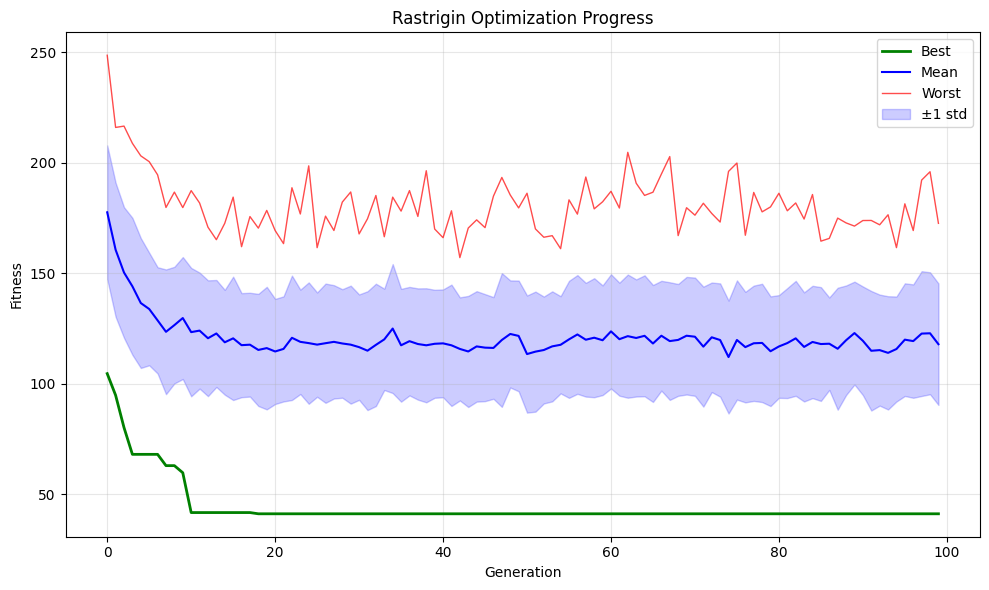

Convergence Analysis:
  Starting fitness (best): 104.6291
  Final fitness (best): 41.262128
  Improvement: 63.3670
  Target (global optimum): 0.0


In [5]:
# Plot fitness history (FR-015)
fig = plot_fitness_history(
    history,
    show_std=True,
    title=f"{benchmark.name} Optimization Progress",
)
plt.show()

# Analysis
print("Convergence Analysis:")
print(f"  Starting fitness (best): {history.best_fitness[0]:.4f}")
print(f"  Final fitness (best): {history.best_fitness[-1]:.6f}")
print(f"  Improvement: {history.best_fitness[0] - history.best_fitness[-1]:.4f}")
print(f"  Target (global optimum): {benchmark.global_optimum}")

In [6]:
# Analyze the best solution found
best_genome = result.best.genome

print("Best solution found:")
print(f"  Genes: {best_genome.genes.round(4)}")
print(f"  Fitness: {result.best.fitness.values[0]:.6f}")
print("\nDistance from true optimum (should be near 0):")
print(f"  L2 distance: {np.linalg.norm(best_genome.genes - benchmark.optimal_position):.6f}")
print(f"  Max deviation: {np.max(np.abs(best_genome.genes - benchmark.optimal_position)):.6f}")

Best solution found:
  Genes: [-0.9809 -1.2796  1.0439  1.0311 -0.9731 -0.6258  0.8966  0.0126 -0.971
  0.9429]
  Fitness: 41.262128

Distance from true optimum (should be near 0):
  L2 distance: 2.954118
  Max deviation: 1.279597


---

## Part 8: Population Diversity (FR-016)

Diversity is crucial for avoiding premature convergence. Let's visualize how diversity changed during evolution.

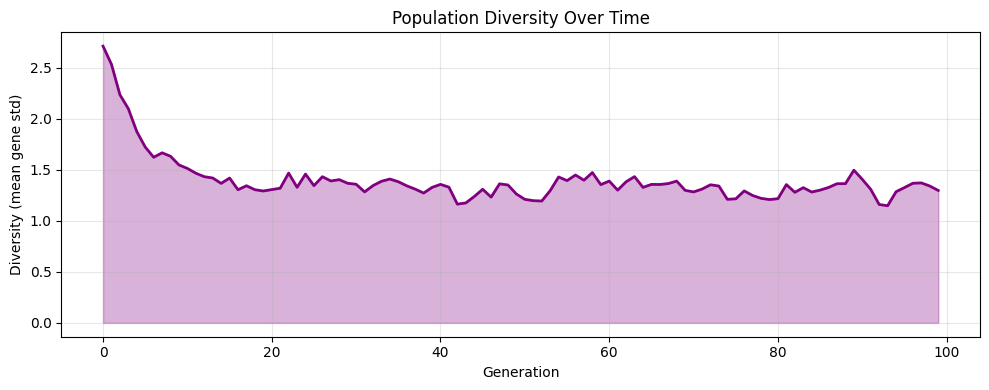


💡 Notice how diversity decreases as the population converges.
   Early: High diversity = exploration
   Late: Low diversity = exploitation (convergence)


In [7]:
# Plot diversity over generations
fig, ax = plt.subplots(figsize=(10, 4))

ax.plot(history.generations, history.diversity, color="purple", linewidth=2)
ax.fill_between(history.generations, 0, history.diversity, alpha=0.3, color="purple")

ax.set_xlabel("Generation")
ax.set_ylabel("Diversity (mean gene std)")
ax.set_title("Population Diversity Over Time")
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n💡 Notice how diversity decreases as the population converges.")
print("   Early: High diversity = exploration")
print("   Late: Low diversity = exploitation (convergence)")

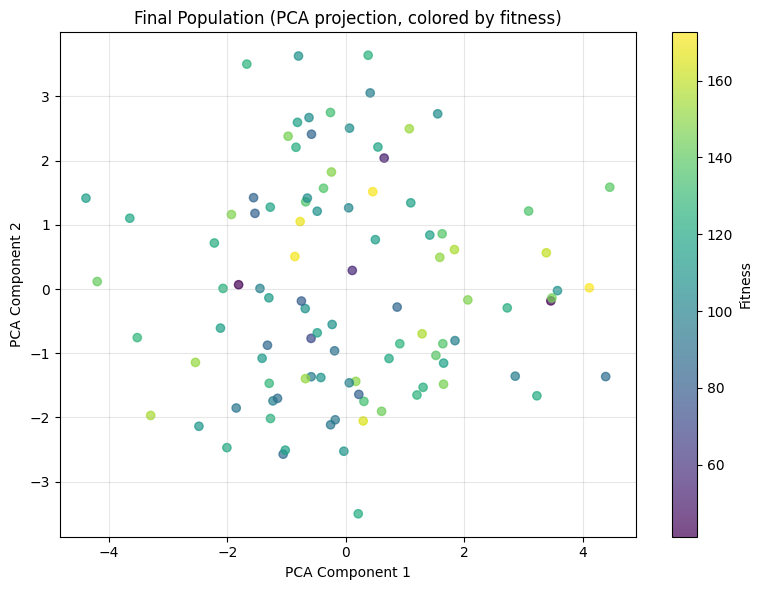

The population has converged to a cluster near the optimum.


In [8]:
# Visualize final population distribution (project to 2D)
final_genomes = np.array([ind.genome.genes for ind in result.population.individuals])
final_fitness = np.array([ind.fitness.values[0] for ind in result.population.individuals])

fig = plot_population_diversity(
    final_genomes,
    method="pca",
    fitness_values=final_fitness,
    title="Final Population (PCA projection, colored by fitness)",
)
plt.show()

print("The population has converged to a cluster near the optimum.")

---

## Part 9: Callbacks for Logging and Early Stopping (FR-017)

Callbacks let you monitor and control evolution. Common uses:
- Logging metrics to TensorBoard/WandB
- Early stopping when converged
- Adaptive parameter adjustment

In [ ]:
# Early stopping via UnifiedConfig + StoppingConfig
from evolve.config.stopping import StoppingConfig

early_stop_config = UnifiedConfig(
    name="early_stopping_demo",
    population_size=50,
    max_generations=200,
    elitism=1,
    selection="tournament",
    selection_params={"tournament_size": 3},
    crossover="uniform",
    mutation="gaussian",
    mutation_params={"sigma": 0.3},
    genome_type="vector",
    genome_params={"dimensions": 5, "bounds": (-5.12, 5.12)},
    stopping=StoppingConfig(
        stagnation_generations=15,  # Stop if no improvement for 15 gens
    ),
    seed=SEED,
)

history2 = EvolutionHistory()
callback2 = MetricsCallback(history2)

engine2 = create_engine(early_stop_config, evaluator=sphere_function, callbacks=[callback2])
initial_pop2 = create_initial_population(early_stop_config)

result2 = engine2.run(initial_pop2)

print(f"\nCompleted in {result2.generations} generations (max was 200)")
print(f"Best fitness: {result2.best.fitness.values[0]:.8f}")
print(f"Stop reason: {result2.stop_reason}")


Early stopping at generation 69: no improvement for 15 generations

Early stopping at generation 70: no improvement for 15 generations

Early stopping at generation 104: no improvement for 15 generations

Early stopping at generation 105: no improvement for 15 generations

Early stopping at generation 106: no improvement for 15 generations

Early stopping at generation 107: no improvement for 15 generations

Early stopping at generation 108: no improvement for 15 generations

Early stopping at generation 109: no improvement for 15 generations

Early stopping at generation 110: no improvement for 15 generations

Early stopping at generation 111: no improvement for 15 generations

Early stopping at generation 112: no improvement for 15 generations

Early stopping at generation 128: no improvement for 15 generations

Early stopping at generation 129: no improvement for 15 generations

Early stopping at generation 130: no improvement for 15 generations

Early stopping at generation 131: n

---

## Part 10: Checkpointing (FR-018)

Checkpointing lets you save and resume evolution runs. Essential for:
- Long-running experiments
- Resuming after crashes
- Comparing configurations

In [10]:
# Demonstrate checkpointing concepts
import json
from datetime import datetime


# Save checkpoint
def save_checkpoint(result, history, filepath):
    """Save evolution state to file."""
    checkpoint = {
        "generation": result.generations,
        "best_fitness": result.best.fitness.values[0],
        "best_genome": result.best.genome.to_dict(),
        "history": {
            "generations": history.generations,
            "best_fitness": history.best_fitness,
            "mean_fitness": history.mean_fitness,
        },
        "timestamp": datetime.now().isoformat(),
    }
    with open(filepath, "w") as f:
        json.dump(checkpoint, f, indent=2)
    return filepath


# Load checkpoint
def load_checkpoint(filepath):
    """Load evolution state from file."""
    with open(filepath) as f:
        return json.load(f)


# Demo
checkpoint_path = "/tmp/evolution_checkpoint.json"
save_checkpoint(result, history, checkpoint_path)
print(f"✓ Checkpoint saved to {checkpoint_path}")

# Verify
loaded = load_checkpoint(checkpoint_path)
print("\nLoaded checkpoint:")
print(f"  Generation: {loaded['generation']}")
print(f"  Best fitness: {loaded['best_fitness']:.6f}")
print(f"  Timestamp: {loaded['timestamp']}")

✓ Checkpoint saved to /tmp/evolution_checkpoint.json

Loaded checkpoint:
  Generation: 100
  Best fitness: 41.262128
  Timestamp: 2026-02-01T11:21:33.354367


---

## Part 11: Island Model Parallelism (FR-020, FR-021, FR-022)

The **Island Model** runs multiple populations in parallel with occasional migration. Benefits:
- Better exploration (diverse islands)
- Natural parallelism
- Prevents premature convergence

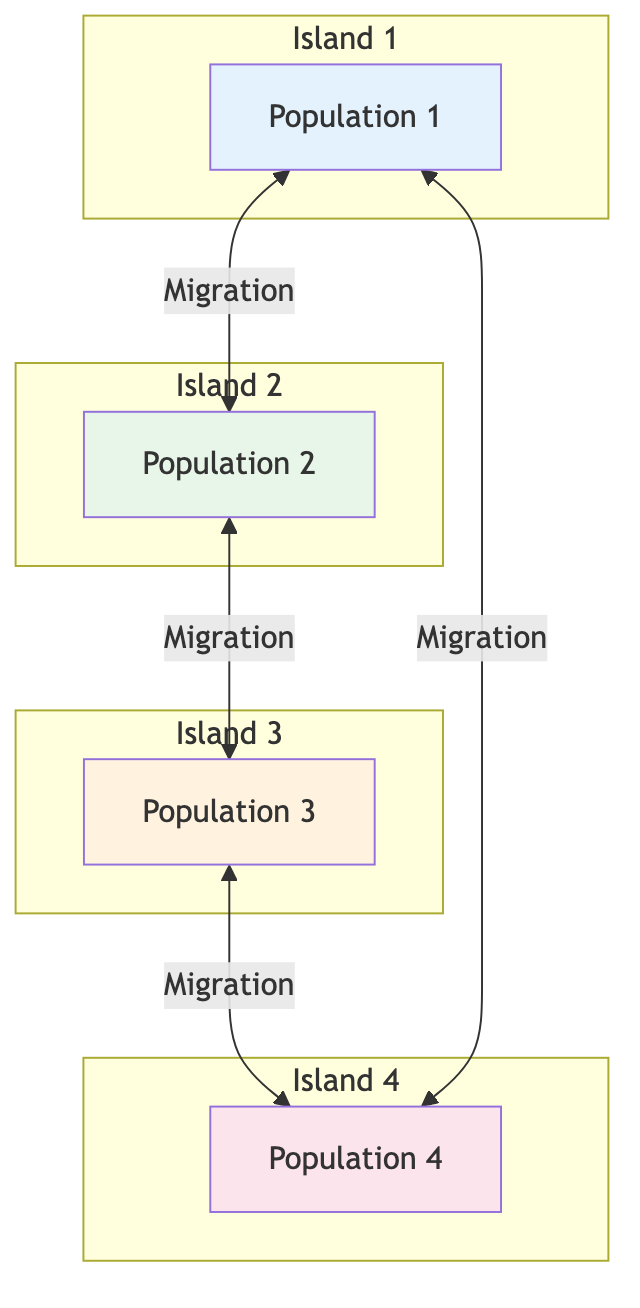

In [11]:
# Visualize island topology
render_mermaid(ISLAND_MODEL_DIAGRAM)

In [12]:
# Compare single population vs island model (simulated)
# Note: Full island implementation uses evolve.diversity.islands

from docs.tutorials.utils.tutorial_utils import create_island_config

# Island configuration: 4 islands × 50 individuals = 200 total
island_config = create_island_config(
    num_islands=4,
    population_per_island=50,
    topology="ring",
    migration_interval=10,
    migration_rate=0.1,
)

print("Island Model Configuration:")
print(f"  Num islands: {island_config.num_islands}")
print(f"  Pop per island: {island_config.population_per_island}")
print(f"  Total population: {island_config.total_population}")
print(f"  Topology: {island_config.topology}")
print(f"  Migration interval: {island_config.migration_interval} generations")
print(f"  Migration rate: {island_config.migration_rate * 100}%")

Island Model Configuration:
  Num islands: 4
  Pop per island: 50
  Total population: 200
  Topology: ring
  Migration interval: 10 generations
  Migration rate: 10.0%


In [ ]:
# Simulate island model by running multiple independent evolutions
# (Full implementation would use proper migration)

print("Comparing single population vs simulated island model...")
print("(Each 'island' runs independently - real implementation would include migration)\n")

bounds = (np.full(10, -5.12), np.full(10, 5.12))

# Single large population via UnifiedConfig
single_config = UnifiedConfig(
    name="single_pop",
    population_size=200,
    max_generations=100,
    selection="tournament",
    selection_params={"tournament_size": 3},
    crossover="uniform",
    mutation="gaussian",
    mutation_params={"sigma": 0.5},
    genome_type="vector",
    genome_params={"dimensions": 10, "bounds": (-5.12, 5.12)},
    seed=SEED,
)

single_history = EvolutionHistory()
single_engine = create_engine(
    single_config, evaluator=rastrigin_function, callbacks=[MetricsCallback(single_history)]
)
single_pop = create_initial_population(single_config)
single_result = single_engine.run(single_pop)

# Four "islands" (simulated) — same config with different seeds
island_histories = []
island_results = []

for i in range(4):
    island_config = UnifiedConfig(
        name=f"island_{i}",
        population_size=50,
        max_generations=100,
        selection="tournament",
        selection_params={"tournament_size": 3},
        crossover="uniform",
        mutation="gaussian",
        mutation_params={"sigma": 0.5},
        genome_type="vector",
        genome_params={"dimensions": 10, "bounds": (-5.12, 5.12)},
        seed=SEED + i,  # Different seed per island
    )

    island_history = EvolutionHistory()
    island_engine = create_engine(
        island_config, evaluator=rastrigin_function, callbacks=[MetricsCallback(island_history)]
    )
    island_pop = create_initial_population(island_config)
    island_result = island_engine.run(island_pop)
    island_histories.append(island_history)
    island_results.append(island_result)

# Best across all islands
best_island_fitness = min(r.best.fitness.values[0] for r in island_results)
best_island_idx = np.argmin([r.best.fitness.values[0] for r in island_results])

print(f"Single population (n=200): {single_result.best.fitness.values[0]:.6f}")
print(f"Best of 4 islands (n=50 each): {best_island_fitness:.6f}")
print(f"  (Best was island {best_island_idx + 1})")

Comparing single population vs simulated island model...
(Each 'island' runs independently - real implementation would include migration)

Single population (n=200): 0.324354
Best of 4 islands (n=50 each): 2.970190
  (Best was island 1)


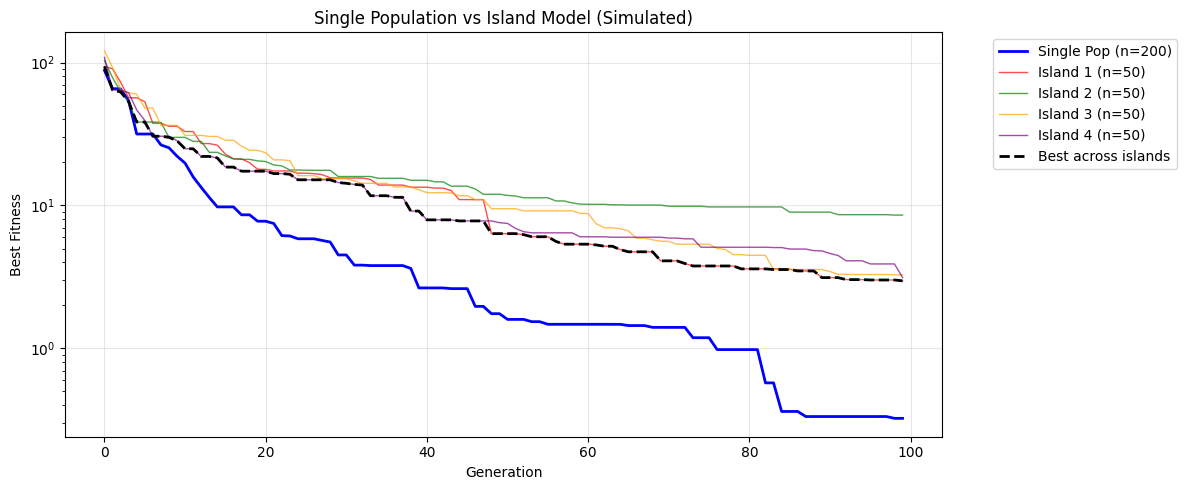


💡 Islands explore different regions, often finding better solutions!


In [14]:
# Visualize comparison
fig, ax = plt.subplots(figsize=(12, 5))

# Single population
ax.plot(
    single_history.generations,
    single_history.best_fitness,
    label="Single Pop (n=200)",
    linewidth=2,
    color="blue",
)

# Islands
colors = ["red", "green", "orange", "purple"]
for i, (hist, color) in enumerate(zip(island_histories, colors)):
    ax.plot(
        hist.generations,
        hist.best_fitness,
        label=f"Island {i + 1} (n=50)",
        linewidth=1,
        alpha=0.7,
        color=color,
    )

# Combined best-so-far across islands
combined_best = np.minimum.accumulate(np.min([h.best_fitness for h in island_histories], axis=0))
ax.plot(
    range(len(combined_best)),
    combined_best,
    label="Best across islands",
    linewidth=2,
    linestyle="--",
    color="black",
)

ax.set_xlabel("Generation")
ax.set_ylabel("Best Fitness")
ax.set_title("Single Population vs Island Model (Simulated)")
ax.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
ax.grid(True, alpha=0.3)
ax.set_yscale("log")

plt.tight_layout()
plt.show()

print("\n💡 Islands explore different regions, often finding better solutions!")

---

## Part 12: GPU Acceleration (FR-024, FR-025, FR-026)

The evolve framework supports GPU acceleration for fitness evaluation. This is most beneficial when:
- Fitness evaluation is computationally expensive
- Population size is large (>1000)
- Evaluation time > 10ms per individual

In [15]:
# Check GPU availability (with graceful degradation)
gpu_info = check_gpu_available()

print("GPU Status:")
print(f"  Available: {gpu_info['available']}")
print(f"  Backend: {gpu_info['backend']}")
print(f"  Device: {gpu_info['device_name']}")
print(f"\n{gpu_info['message']}")

GPU Status:
  Available: False
  Backend: cpu
  Device: CPU

No GPU detected. Running in CPU mode.
GPU sections will show placeholder benchmarks.
Install PyTorch CUDA or JAX with GPU support for acceleration.


In [ ]:
# Benchmark timing (placeholder for CPU/GPU comparison)
import time

# Measure CPU baseline
large_pop_size = 1000
n_generations = 50

bench_config = UnifiedConfig(
    name="cpu_benchmark",
    population_size=large_pop_size,
    max_generations=n_generations,
    selection="tournament",
    selection_params={"tournament_size": 3},
    crossover="uniform",
    mutation="gaussian",
    mutation_params={"sigma": 0.5},
    genome_type="vector",
    genome_params={"dimensions": 20, "bounds": (-5.12, 5.12)},
    seed=SEED,
)

start_time = time.time()

cpu_engine = create_engine(bench_config, evaluator=rastrigin_function)
cpu_pop = create_initial_population(bench_config)
cpu_result = cpu_engine.run(cpu_pop)

cpu_time = time.time() - start_time

cpu_benchmark = BenchmarkResult(
    configuration="CPU-Sequential",
    total_time_seconds=cpu_time,
    generations=n_generations,
    population_size=large_pop_size,
    final_best_fitness=cpu_result.best.fitness.values[0],
)

print(f"CPU Benchmark (20D Rastrigin, pop={large_pop_size}, gens={n_generations}):")
print(f"  Total time: {cpu_benchmark.total_time_seconds:.2f}s")
print(f"  Gens/sec: {cpu_benchmark.generations_per_second:.1f}")
print(f"  Final fitness: {cpu_benchmark.final_best_fitness:.6f}")

if gpu_info["available"]:
    print("\n🚀 With GPU acceleration, expect 3-10x speedup for large populations!")
else:
    print("\n💡 GPU not available. Install PyTorch CUDA or JAX GPU for acceleration.")

CPU Benchmark (20D Rastrigin, pop=1000, gens=50):
  Total time: 15.00s
  Gens/sec: 3.3
  Final fitness: 15.038951

💡 GPU not available. Install PyTorch CUDA or JAX GPU for acceleration.


---

## Part 13: Extensions and Next Steps (FR-019)

Congratulations! You've learned the fundamentals of evolutionary optimization with VectorGenome.

### What You've Learned

- ✅ EA concepts mapped to ML equivalents
- ✅ VectorGenome for continuous optimization
- ✅ Mutation and crossover operators
- ✅ Running evolution with EvolutionEngine
- ✅ Visualizing convergence and diversity
- ✅ Using callbacks for logging and early stopping
- ✅ Checkpointing evolution runs
- ✅ Island model parallelism
- ✅ GPU acceleration options

### Next Tutorials

| Tutorial | Representation | Key Concepts |
|----------|----------------|-------------|
| **02_sequence_genome** | Variable-length sequences | Genetic programming, expression trees |
| **03_graph_genome_neat** | Neural networks | NEAT, neuroevolution, speciation |
| **04_rl_neuroevolution** | Policy networks | RL without gradients, gymnasium |
| **05_scm_multiobjective** | Causal graphs | Multi-objective, Pareto fronts |

In [17]:
# Summary statistics
print("=" * 60)
print("TUTORIAL COMPLETE: VectorGenome Continuous Optimization")
print("=" * 60)
print(f"\nBenchmark: {benchmark.name} ({n_dims}D)")
print(f"Best fitness achieved: {result.best.fitness.values[0]:.8f}")
print(f"Global optimum: {benchmark.global_optimum}")
print(
    f"Distance to optimum: {np.linalg.norm(result.best.genome.genes - benchmark.optimal_position):.6f}"
)
print("\n✓ You're ready to explore more complex representations!")

TUTORIAL COMPLETE: VectorGenome Continuous Optimization

Benchmark: Rastrigin (10D)
Best fitness achieved: 41.26212751
Global optimum: 0.0
Distance to optimum: 2.954118

✓ You're ready to explore more complex representations!
